<a href="https://colab.research.google.com/github/pkorotkow/statprak/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **[Water Quality.](https://www.kaggle.com/datasets/adityakadiwal/water-potability?resource=download) Исследование качества воды.**

**Задача**: бинарная классификация пригодности воды для потребления

## **Загрузка и препроцессинг**

Вставлю готовый код, который у меня получился в результате EDA с заполнением пропусков медианой своего класса

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('water_potability.csv')

cols_with_nan = ['ph', 'Sulfate', 'Trihalomethanes']

for col in cols_with_nan:
    df[col] = df[col].fillna(df.groupby('Potability')[col].transform('median'))

## **Выделение признаков и таргета, разделение на Train и Test, нормализация**

1) Делю на train и test в соотношении 80/20
2) Сохраняю соотношение классов в трейне и тесте с помощью stratify
3) Так как буду использовать алгоритмы, которые чувствительны к масштабу (логистическая регрессия, kNN), то сделаю Standart Scaling
4) Обеспечиваю воспроизводимость с помощью Random State

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Potability', axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер трейна: {X_train_scaled.shape}, Размер теста: {X_test_scaled.shape}")

Размер трейна: (2620, 9), Размер теста: (656, 9)


## **Logistic Regression**

Обучение Logistic Regression...
Лучшие параметры LR: {'C': 0.001, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}

=== Результат по лучшей модели Logistic Regression ===
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656

ROC-AUC Score: 0.5000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


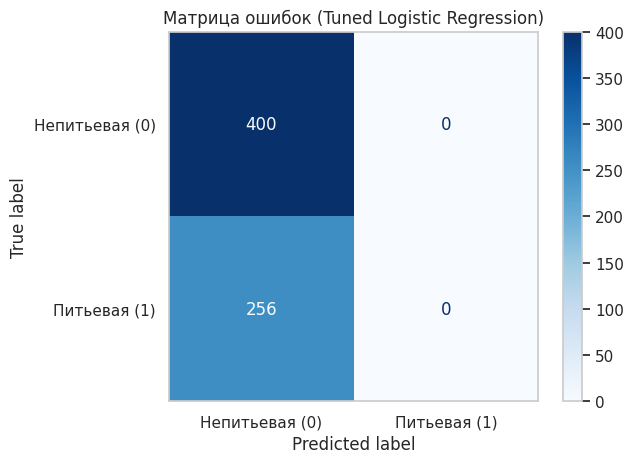

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

log_reg = LogisticRegression(random_state=42, max_iter=2000)

grid_search_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)

print("Обучение Logistic Regression...")
grid_search_lr.fit(X_train_scaled, y_train)

print(f"Лучшие параметры LR: {grid_search_lr.best_params_}")

best_lr = grid_search_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test_scaled)
y_pred_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

print("\n=== Результат по лучшей модели Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_lr):.4f}\n")

disp_lr = ConfusionMatrixDisplay.from_estimator(
    best_lr, X_test_scaled, y_test,
    display_labels=['Непитьевая (0)', 'Питьевая (1)'],
    cmap='Blues', values_format='d'
)
plt.title('Матрица ошибок (Tuned Logistic Regression)')
plt.grid(False)
plt.show()

### Вывод

Логистическая регрессия оказалась абсолютно бесполезна на данном датасете, как и предполагалось еще в EDA.

Так как распределения признаков перекрывают друг друга, а корреляция их с целевой переменной почти нулевая, Логистическая регрессия, минимизируя логлосс, выродилась в то, что стала предсказывать класс по априорной вероятности классов. Так как непитьевой воды 60%, то есть больше, то все точки из теста получилии вероятности примерно 0.4, что классифицировалось моделью как непитьевая вода.

## **kNN с подбором гиперпараметров**

Попробуем метрические алгоритмы, один из которых kNN. Для того, чтобы извлечь максимум эффективности из этого алгоритма, использую GridSearch, который протестирует модель на разных гиперпараметрах и проведет кросс-валидацию для максимально объективной оценки модели.

Лучшие параметры kNN: {'n_neighbors': 49, 'weights': 'distance'}

=== kNN (Лучшая модель) ===
              precision    recall  f1-score   support

           0       0.64      0.95      0.76       400
           1       0.68      0.15      0.24       256

    accuracy                           0.64       656
   macro avg       0.66      0.55      0.50       656
weighted avg       0.65      0.64      0.56       656

ROC-AUC Score: 0.6283



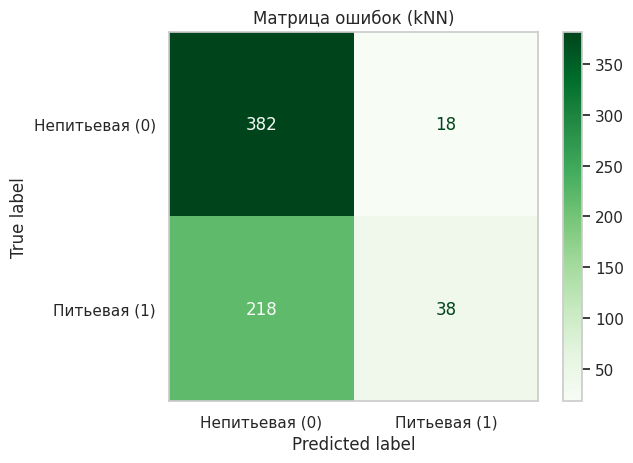

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': range(5, 61, 2),
              'weights': ['uniform', 'distance']}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print(f"Лучшие параметры kNN: {grid_search.best_params_}")

best_knn = grid_search.best_estimator_

y_pred_knn = best_knn.predict(X_test_scaled)
y_pred_proba_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

print("\n=== kNN (Лучшая модель) ===")
print(classification_report(y_test, y_pred_knn))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_knn):.4f}\n")

disp_knn = ConfusionMatrixDisplay.from_estimator(
    best_knn, X_test_scaled, y_test,
    display_labels=['Непитьевая (0)', 'Питьевая (1)'],
    cmap='Greens', values_format='d'
)
plt.title('Матрица ошибок (kNN)')
plt.grid(False)
plt.show()

### Вывод

1) Мы получили существенный прирост метрик по сравнению с Логистической регрессией, которая была абсолютно бесполезна. Это в очередной раз подтверждает гипотезу: в данных присутствуют сложные нелинейные зависимости, которые kNN частично удалось даже уловить. Метрика ROC-AUC выросла с 0.51 (полной случайности) до 0.63.

2) Как можно заметить по Confusion Matrix, модель ведет себя очень осторожно. Мы имеем целых 218 FN, и всего 38 TP. Иначе говоря, 68% воды из всей, которую алгоритм определил питьевой, действительно оказалась питьевой, но он нашел всего 15% всей питьевой воды!

3) Так как данные зашумлены и сложны, для kNN оптимальным числом соседей оказалось достаточно большое число -- целых 49.

## **Random Forest**

Так как данные обладают сложной нелинейной зависимостью и мы в результате EDA решили оставить выбросы, то уж очень хорошим для решения проблемы бинарной классификации кажется Random Forest, который слабо чувствителен к выбросам и масштабу данных.

Обучение Random Forest...
Лучшие параметры Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}

=== Результат по лучшей модели Random Forest ===
              precision    recall  f1-score   support

           0       0.79      0.93      0.85       400
           1       0.85      0.61      0.71       256

    accuracy                           0.80       656
   macro avg       0.82      0.77      0.78       656
weighted avg       0.81      0.80      0.80       656

ROC-AUC Score: 0.8723



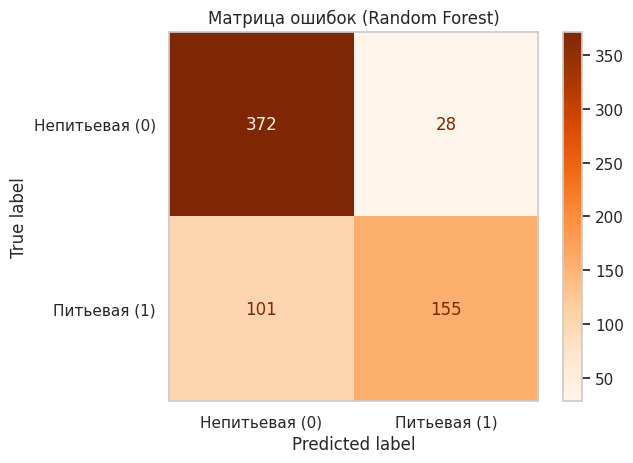

In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)

print("Обучение Random Forest...")
grid_search_rf.fit(X_train_scaled, y_train)

print(f"Лучшие параметры Random Forest: {grid_search_rf.best_params_}")

best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

print("\n=== Результат по лучшей модели Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}\n")

disp_rf = ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test_scaled, y_test,
    display_labels=['Непитьевая (0)', 'Питьевая (1)'],
    cmap='Oranges', values_format='d'
)
plt.title('Матрица ошибок (Random Forest)')
plt.grid(False)
plt.show()

### Вывод

1) Мы получили очень хороший результат, ROC-AUC score составил целых 0.87. Метрика Precision равна 0.85, то есть из всей воды, которую модель пометила пригодной для питья, целых 85% действительно такой оказалось. Более того, даже Recall оказался не так уж и плох, было найдено верно 61% всей чистой воды. Ансамблевый алгоритм Random Forest прекрасно отработал на данном датасете и получил хорошие результаты (особенно относительно логистической регрессии)

2) GridSearch выдал лучшие гиперпараметры: 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200. Это значит, что алгоритму потребовалось строить максимально глубокие и детализированные деревья для поиска скрытых связей в зашумленных данных.


Так как у случайного леса есть возможность посмотреть, какие признаки оказались самыми важными для принятия решения, не упущу эту возможность

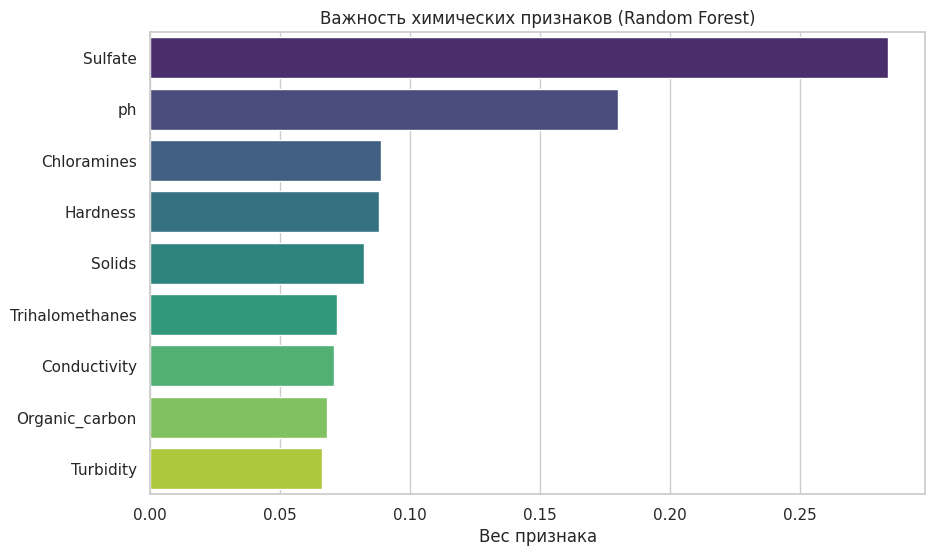

In [ ]:
importances = best_rf.feature_importances_
features = X.columns

feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis', hue = 'Feature')
plt.title('Важность химических признаков (Random Forest)')
plt.xlabel('Вес признака')
plt.ylabel('')
plt.show()

## **Выводы**

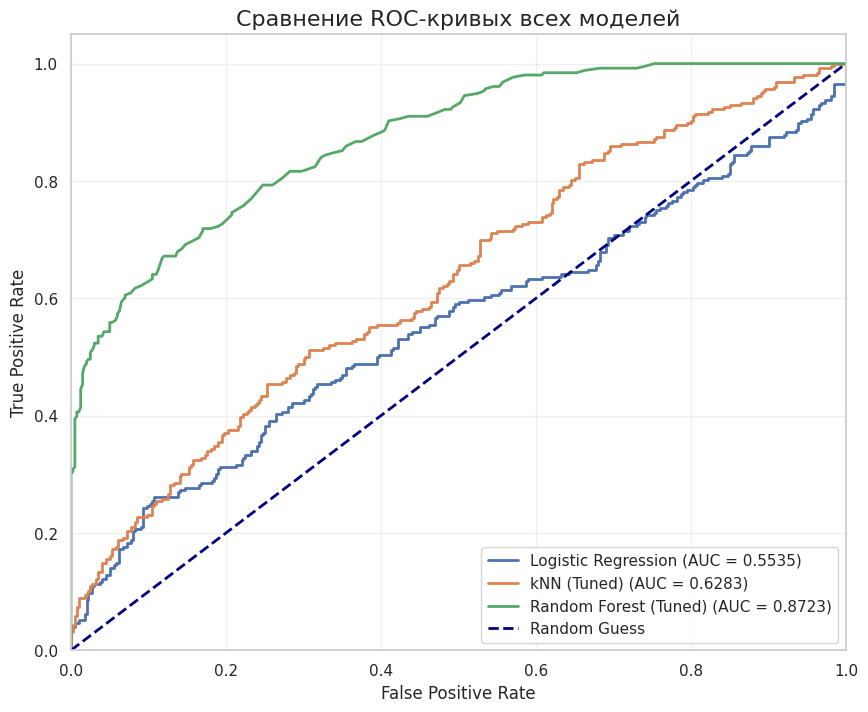

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(10, 8))

models_to_plot = [
    ('Logistic Regression', y_pred_proba),
    ('kNN (Tuned)', y_pred_proba_knn),
    ('Random Forest (Tuned)', y_pred_proba_rf)
]

for name, proba in models_to_plot:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', lw=2)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Сравнение ROC-кривых всех моделей', fontsize=16)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

1) Логистической регрессии не удалось построить нормальную разделяющую гиперплоскость из-за отсутвия корреляций и выродилась в предсказание мажоритарного класса. Переход к метрическому kNN помогло улучшить ситуацию и модель показала себя лучше, чем «случайность». Но использование ансамблевого случайного леса дало сильный прирост и показало реально значимую эффективность модели. Это наводит на мысли дальше тестировать ансамблевые алгоритмы, н-р градиентный бустинг.

2) Несмотря на сложную структуру ансамбля, случайный лес позволяет посмотреть, какие признаки внесли наибольший вклад в уменьшение функции неопределенности. Как можно видеть, уровень сульфатов (Sulfate), кислотность (pH) и Жесткость (Hardness) играют решающую роль в определении качества воды. Остальные элементы выступают в роли корректирующих весов.